# Real-Data Verification V1 — Implied-Volatility Smile

Every pricing claim in this lab was made in a **synthetic world** (GBM / Merton-jump /
Heston).  This is the first real-data check: does the volatility **smile** that real SPY
options trade at look like what our jump and stochastic-vol models predict — and does
flat-vol Black-Scholes visibly fail?

The discriminating test is the **short-dated skew**.  Equity index smiles are steepest at
short maturity, and the two model families generate skew by different mechanisms:

- **Merton** — a Poisson chance of a sudden *gap*; a negative mean jump tilts the
  distribution left → skew that is strongest at short maturity.
- **Heston** — diffusive stochastic vol correlated with spot (ρ<0); its skew *builds up*
  with maturity and is structurally flat at short maturity.
- **Black-Scholes** — one σ, so its "smile" is a flat line.

**Procedure.** One dated SPY chain (cached for offline reproducibility) → back out the
market smile → fit Merton `(σ,λ,μ_J,δ_J)` and calibrate Heston `(κ,θ,ξ,ρ,v₀)` to a liquid
short-dated expiry → compare against a flat BS line.

**What we expect.** All three measured in implied-vol RMSE (vol points).  Merton should
fit the steep short skew tightly; Heston should bend the right way (ρ<0) but underfit a
short-dated skew this steep; flat BS should miss the wings badly.

> Reproducibility: the snapshot is pinned to `DATE` and cached under `data/cache/`
> (gitignored).  After the first fetch the notebook is offline and deterministic; CI never
> runs it.  SPY options are American and the index pays dividends — see the caveats.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

from scipy.optimize import least_squares

from config import DEFAULT_RISK_FREE_RATE as r
from data.fetcher import fetch_and_cache
from ml.vol_surface_nn import fetch_vol_surface
from models.black_scholes import BlackScholes
from models.heston import Heston, HestonCalibrator
from models.merton import MertonJumpDiffusion

COLORS = {"market": "black", "merton": "goldenrod", "heston": "darkorange", "bs": "steelblue"}

# Pinned snapshot date — the cache key, so every re-run hits the same parquet.
DATE = "2026-06-20"
print("r =", round(r, 4), "  snapshot DATE =", DATE)

r = 0.0438   snapshot DATE = 2026-06-20


## 1. Fetch the SPY implied-volatility surface

`fetch_vol_surface` pulls the live SPY call chain, keeps liquid quotes
(`bid>0 & ask>0 & volume>10`, moneyness ∈ [0.7, 1.3]) and backs out the Black-Scholes
implied vol from each mid price.  `fetch_and_cache` pins the result to a dated parquet so
everything below is offline and reproducible.

In [2]:
surface = fetch_and_cache("SPY", "vol_surface", DATE,
                          lambda: fetch_vol_surface("SPY", r))
S = float(surface["S"].iloc[0])
dte = (surface.groupby("expiry")["T"].first() * 365).round().astype(int)
print("Spot S =", round(S, 2), " | ", len(surface), "liquid quotes across",
      surface["expiry"].nunique(), "expiries")
surface.head()

Spot S = 746.74  |  1633 liquid quotes across 31 expiries


,moneyness,T,log_T,IV,strike,expiry,S
0,0.917321,0.00274,-5.899897,1.085094,685.0,2026-06-22,746.73999
1,0.924016,0.00274,-5.899897,1.014698,690.0,2026-06-22,746.73999
2,0.930712,0.00274,-5.899897,0.935010,695.0,2026-06-22,746.73999
3,0.937408,0.00274,-5.899897,0.864772,700.0,2026-06-22,746.73999
4,0.949460,0.00274,-5.899897,0.737972,709.0,2026-06-22,746.73999


## 2. The skew steepens at short maturity

Plotting market IV against moneyness, coloured by days-to-expiry, shows the term structure
of skew: the **short-dated** smiles are the steepest.  That is exactly where jumps and
diffusive stochastic vol disagree, so we calibrate to a liquid short-dated expiry.

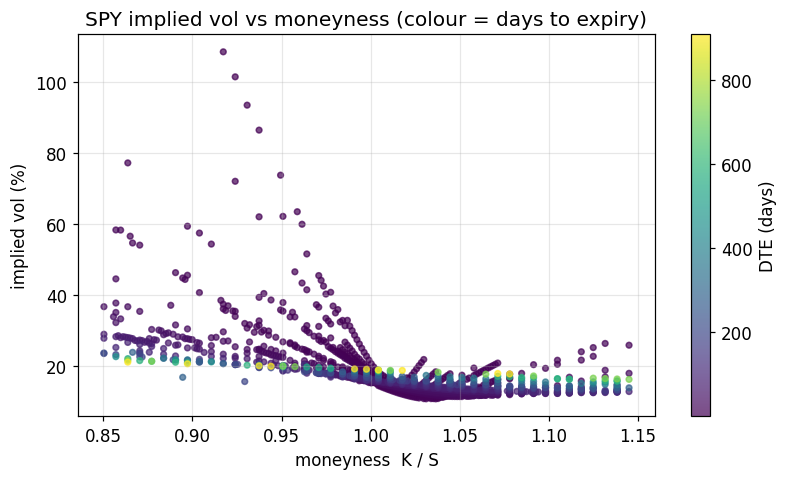

In [3]:
band = surface[surface["moneyness"].between(0.85, 1.15)]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sc = ax.scatter(band["moneyness"], band["IV"] * 100, c=band["T"] * 365,
                cmap="viridis", s=14, alpha=0.7)
ax.set_xlabel("moneyness  K / S"); ax.set_ylabel("implied vol (%)")
ax.set_title("SPY implied vol vs moneyness (colour = days to expiry)")
ax.grid(alpha=0.3); plt.colorbar(sc, label="DTE (days)")
plt.tight_layout(); plt.show()

## 3. Select a liquid short-dated expiry

Nearest expiry to ~35 days with enough liquid strikes; restrict to moneyness ∈ [0.85, 1.15]
(deep wings carry the largest American / liquidity bias) and thin to ≤14 strikes for a
tractable Heston calibration.

In [4]:
counts = surface.groupby("expiry").size()
liquid = [e for e in dte.index if counts[e] >= 8]
rep = min(liquid, key=lambda e: abs(dte[e] - 35))

d = surface[(surface["expiry"] == rep) & surface["moneyness"].between(0.85, 1.15)].sort_values("strike")
if len(d) > 14:
    d = d.iloc[np.linspace(0, len(d) - 1, 14).round().astype(int)]
K   = d["strike"].to_numpy(float)
T   = float(d["T"].iloc[0])
mny = K / S
miv = d["IV"].to_numpy(float)
skew_slope = np.polyfit(mny, miv, 1)[0]
print("representative expiry", rep, "(", int(dte[rep]), "days ),  N =", len(d),
      " moneyness", round(mny.min(), 2), "-", round(mny.max(), 2))
print("market skew slope dIV/d(moneyness) =", round(skew_slope, 3),
      "(downward equity skew)" if skew_slope < 0 else "(upward)")

representative expiry 2026-07-24 ( 33 days ),  N = 14  moneyness 0.85 - 1.12
market skew slope dIV/d(moneyness) = -0.923 (downward equity skew)


## 4. Fit Merton jump-diffusion to the smile

Fit `(σ, λ, μ_J, δ_J)` by least squares directly on implied vol.  A negative mean jump
`μ_J` produces the downward skew; jump dispersion `δ_J` fattens the wings.

In [5]:
def merton_iv(params, k, t):
    sig, lam, mu, dj = params
    price = MertonJumpDiffusion(S, k, t, r, sig, lam, mu, dj).price("call")
    iv = BlackScholes(S, k, t, r, sigma=0.2).implied_vol(price, "call")
    return iv if iv == iv else 1.0          # guard NaN for the optimiser

sol = least_squares(
    lambda p: np.array([merton_iv(p, k, T) for k in K]) - miv,
    x0=[float(np.median(miv)), 1.0, -0.10, 0.15],
    bounds=([0.01, 0.0, -0.90, 0.001], [1.0, 30.0, 0.50, 1.0]),
    xtol=1e-10, ftol=1e-10)
sig_m, lam_m, mu_m, dj_m = sol.x
merton_iv_pts = np.array([merton_iv(sol.x, k, T) for k in K])
merton_rmse = np.sqrt(np.nanmean((merton_iv_pts - miv) ** 2))
print("Merton:  sigma =", round(sig_m, 4), " lambda =", round(lam_m, 3),
      " mu_J =", round(mu_m, 4), " delta_J =", round(dj_m, 4))
print("  ->", round(lam_m, 2), "jumps/yr, mean jump", round((np.exp(mu_m) - 1) * 100, 1),
      "% (negative = down-gap skew)")
print("Merton IV-RMSE =", round(merton_rmse * 100, 3), "vol points")

Merton:  sigma = 0.0993  lambda = 0.885  mu_J = -0.1652  delta_J = 0.1213
  -> 0.89 jumps/yr, mean jump -15.2 % (negative = down-gap skew)
Merton IV-RMSE = 0.38 vol points


## 5. Calibrate Heston to the smile

`HestonCalibrator` minimises ATM-weighted IV-RMSE over `(κ,θ,ξ,ρ,v₀)` with differential
evolution and a soft Feller penalty.  ρ<0 bends the surface into a downward skew.  (DE
budget kept modest: on a skew this steep the fit does not improve with more iterations —
Heston is at its structural limit, not its optimiser's.)

In [6]:
cal = HestonCalibrator(r=r, de_maxiter=50, de_popsize=12)
hp = cal.calibrate(S, K, np.full_like(K, T), miv, verbose=False)
heston_iv_pts = np.array([Heston(S, k, T, r, hp).implied_vol() for k in K])
heston_rmse = np.sqrt(np.nanmean((heston_iv_pts - miv) ** 2))
print("Heston:  kappa =", round(hp.kappa, 3), " theta =", round(hp.theta, 4),
      " xi =", round(hp.xi, 3), " rho =", round(hp.rho, 3), " v0 =", round(hp.v0, 4),
      " (Feller", "ok)" if hp.feller_condition else "violated)")
print("  long-run vol sqrt(theta) =", round(np.sqrt(hp.theta) * 100, 1),
      "%  | spot-vol corr rho =", round(hp.rho, 2))
print("Heston IV-RMSE =", round(heston_rmse * 100, 3), "vol points")

Heston:  kappa = 4.929  theta = 0.1328  xi = 1.133  rho = -0.803  v0 = 0.0092  (Feller ok)
  long-run vol sqrt(theta) = 36.4 %  | spot-vol corr rho = -0.8
Heston IV-RMSE = 2.759 vol points


## 6. Black-Scholes flat-vol baseline

One σ → a horizontal line.  Pinned at the ATM implied vol, the fairest flat number.

In [7]:
atm_iv = float(d.iloc[int(np.abs(mny - 1.0).argmin())]["IV"])
bs_rmse = np.sqrt(np.nanmean((atm_iv - miv) ** 2))
print("BS flat vol (ATM) =", round(atm_iv * 100, 2), "%")
print("BS-flat IV-RMSE =", round(bs_rmse * 100, 3), "vol points")

BS flat vol (ATM) = 15.84 %
BS-flat IV-RMSE = 6.162 vol points


## 7. Market vs model implied-vol smile

Market quotes (dots) against the fitted Merton and calibrated Heston curves (evaluated on a
dense moneyness grid) and the flat BS line.

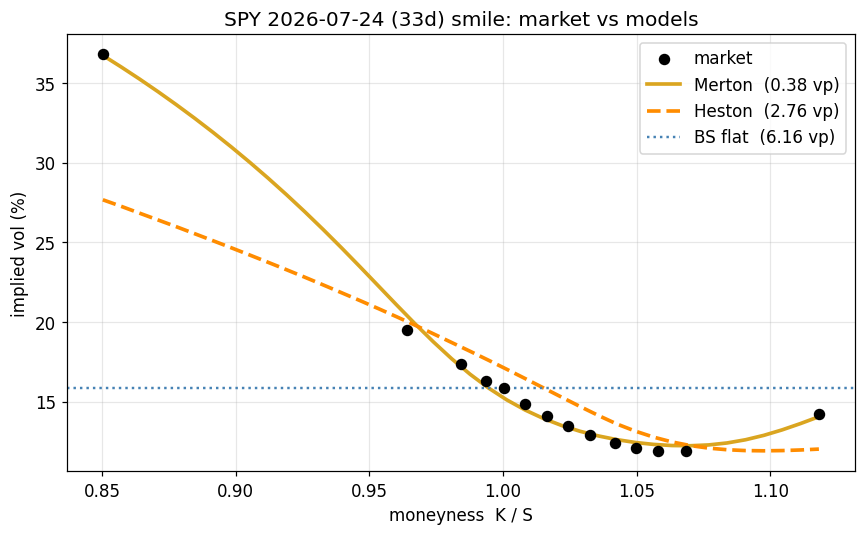

In [8]:
grid_m = np.linspace(mny.min(), mny.max(), 40)
grid_K = grid_m * S
merton_curve = np.array([merton_iv(sol.x, k, T) for k in grid_K]) * 100
heston_curve = np.array([Heston(S, k, T, r, hp).implied_vol() for k in grid_K]) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(mny, miv * 100, s=42, color=COLORS["market"], zorder=4, label="market")
ax.plot(grid_m, merton_curve, color=COLORS["merton"], lw=2.4,
        label=f"Merton  ({merton_rmse*100:.2f} vp)")
ax.plot(grid_m, heston_curve, color=COLORS["heston"], lw=2.4, ls="--",
        label=f"Heston  ({heston_rmse*100:.2f} vp)")
ax.axhline(atm_iv * 100, color=COLORS["bs"], lw=1.6, ls=":",
           label=f"BS flat  ({bs_rmse*100:.2f} vp)")
ax.set_xlabel("moneyness  K / S"); ax.set_ylabel("implied vol (%)")
ax.set_title(f"SPY {rep} ({int(dte[rep])}d) smile: market vs models")
ax.grid(alpha=0.3); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

## 8. Verdict

How far each model's implied vol sits from the market smile, and the realised skew.

In [9]:
summary = pd.DataFrame({
    "IV-RMSE (vol pts)": {"Merton": merton_rmse * 100, "Heston": heston_rmse * 100,
                          "BS flat": bs_rmse * 100},
    "skew mechanism":    {"Merton": "jumps (mu_J<0)", "Heston": f"stoch-vol (rho={hp.rho:.2f})",
                          "BS flat": "none (single sigma)"},
})
print(summary.to_string())
print()
print("market downward skew reproduced :", skew_slope < 0, "  (slope", round(skew_slope, 3), ")")
print("Merton fits the short skew (<1 vp):", merton_rmse * 100 < 1.0)
print("Heston bends right way but underfits:", (hp.rho < 0) and (heston_rmse > 1.5 * merton_rmse))
print("flat BS clearly worst            :", bs_rmse > 1.5 * max(merton_rmse, heston_rmse))
print()
print("V1 finding: the real SPY short-dated smile is steep and downward-skewed.")
print("Jumps (Merton) reproduce it tightly; diffusive stochastic vol (Heston) bends the")
print("right way (rho<0) but structurally underfits a skew this steep at short maturity;")
print("flat Black-Scholes misses the wings entirely.")

         IV-RMSE (vol pts)         skew mechanism
Merton            0.380161         jumps (mu_J<0)
Heston            2.759415  stoch-vol (rho=-0.80)
BS flat           6.162347    none (single sigma)

market downward skew reproduced : True   (slope -0.923 )
Merton fits the short skew (<1 vp): True
Heston bends right way but underfits: True
flat BS clearly worst            : True

V1 finding: the real SPY short-dated smile is steep and downward-skewed.
Jumps (Merton) reproduce it tightly; diffusive stochastic vol (Heston) bends the
right way (rho<0) but structurally underfits a skew this steep at short maturity;
flat Black-Scholes misses the wings entirely.


## Caveats (academic honesty)

- **American vs European.** SPY options are American; our pricers are European.  For
  short-dated near-ATM calls the early-exercise premium is small, but it biases the
  backed-out IV slightly — one reason we drop the deep wings (moneyness outside [0.85, 1.15]).
- **Dividends.** SPY pays dividends; our models assume `q = 0`, so the backed-out IV carries
  a small forward/dividend bias (mostly a level shift, not a skew artefact).
- **Heston at short maturity.** Heston's skew builds with maturity; matching a 1-month skew
  this steep forces a high θ/ξ (near-degenerate long-run vol).  The ~2 vol-point miss is the
  model's structural short-dated limitation, not an optimiser failure — which is precisely
  why the jump mechanism fits better here.
- **Liquidity / staleness.** Quotes and the underlying close are non-synchronous; one dated
  snapshot, not a claim about every regime — just that on this date the real smile is the
  skewed, fat-tailed shape jumps and stoch-vol are built to produce and flat BS is not.